In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
data = pd.read_csv("student-por.csv", sep=";")

FileNotFoundError: [Errno 2] No such file or directory: 'student-por.csv'

In [ ]:
data.head()

In [4]:
data.to_csv("output.csv")

In [5]:
df = data[["studytime" , "failures" , "activities" , "internet" , "absences" ,"goout" , "G1" , "G2" , "G3"]]
df.head()

,studytime,failures,activities,internet,absences,goout,G1,G2,G3
0,2,0,no,no,4,4,0,11,11
1,2,0,no,yes,2,3,9,11,11
2,2,0,no,yes,6,2,12,13,12
3,3,0,yes,yes,0,2,14,14,14
4,2,0,no,no,0,2,11,13,13


In [6]:
df["activities"] = df["activities"].replace({"yes":1 , "no":0})
df['internet']=df['internet'].replace({"yes":1 , "no":0})
df.head()

C:\Users\itsar\AppData\Local\Temp\ipykernel_10848\1832049990.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["activities"] = df["activities"].replace({"yes":1 , "no":0})
C:\Users\itsar\AppData\Local\Temp\ipykernel_10848\1832049990.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["activities"] = df["activities"].replace({"yes":1 , "no":0})
C:\Users\itsar\AppData\Local\Temp\ipykernel_10848\1832049990.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version.

,studytime,failures,activities,internet,absences,goout,G1,G2,G3
0,2,0,0,0,4,4,0,11,11
1,2,0,0,1,2,3,9,11,11
2,2,0,0,1,6,2,12,13,12
3,3,0,1,1,0,2,14,14,14
4,2,0,0,0,0,2,11,13,13


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   studytime   649 non-null    int64
 1   failures    649 non-null    int64
 2   activities  649 non-null    int64
 3   internet    649 non-null    int64
 4   absences    649 non-null    int64
 5   goout       649 non-null    int64
 6   G1          649 non-null    int64
 7   G2          649 non-null    int64
 8   G3          649 non-null    int64
dtypes: int64(9)
memory usage: 45.8 KB


In [8]:
df.describe()

,studytime,failures,activities,internet,absences,goout,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,1.930663,0.221880,0.485362,0.767334,3.659476,3.184900,11.399076,11.570108,11.906009
std,0.829510,0.593235,0.500171,0.422857,4.640759,1.175766,2.745265,2.913639,3.230656
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,1.000000,0.000000,2.000000,10.000000,10.000000,10.000000
50%,2.000000,0.000000,0.000000,1.000000,2.000000,3.000000,11.000000,11.000000,12.000000
75%,2.000000,0.000000,1.000000,1.000000,6.000000,4.000000,13.000000,13.000000,14.000000
max,4.000000,3.000000,1.000000,1.000000,32.000000,5.000000,19.000000,19.000000,19.000000


In [9]:
df= df.drop_duplicates()

In [10]:
df= df.dropna()

In [11]:
cat_col = []
num_col = []
for i in df.columns:
    print(f"values in {i}")
    print(df[i].value_counts())
    print(len(df[i].value_counts()))
    if(len(df[i].value_counts()) > 8):
        num_col.append(i)
    else:
        cat_col.append(i)


values in studytime
studytime
2    297
1    209
3     96
4     35
Name: count, dtype: int64
4
values in failures
failures
0    537
1     70
2     16
3     14
Name: count, dtype: int64
4
values in activities
activities
0    327
1    310
Name: count, dtype: int64
2
values in internet
internet
1    487
0    150
Name: count, dtype: int64
2
values in absences
absences
0     236
2     110
4      92
6      47
8      41
10     21
1      12
12     12
5      12
16     10
14      8
9       7
3       7
11      5
18      3
7       3
21      2
15      2
22      2
30      1
26      1
24      1
13      1
32      1
Name: count, dtype: int64
24
values in goout
goout
3    198
2    142
4    139
5    110
1     48
Name: count, dtype: int64
5
values in G1
G1
10    93
11    87
12    79
14    71
13    71
9     64
8     42
15    35
7     33
16    22
17    15
6      9
18     7
5      5
4      2
0      1
19     1
Name: count, dtype: int64
17
values in G2
G2
11    101
12     81
10     81
13     79
9      71
14    

In [12]:
print(cat_col)

['studytime', 'failures', 'activities', 'internet', 'goout']


In [13]:
print(num_col)

['absences', 'G1', 'G2', 'G3']


Countplot for studytime


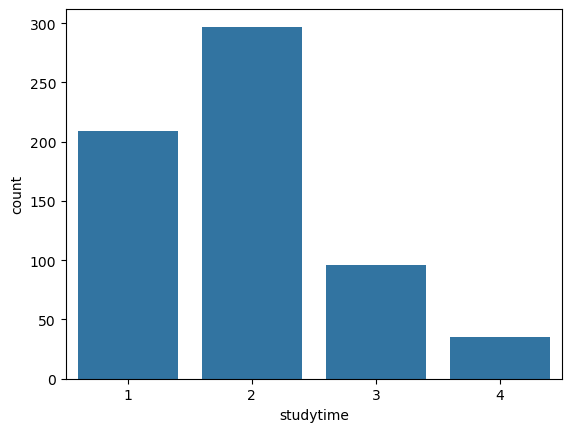

Countplot for failures


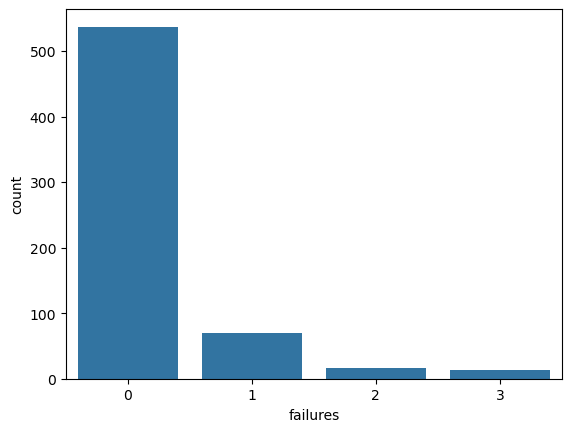

Countplot for activities


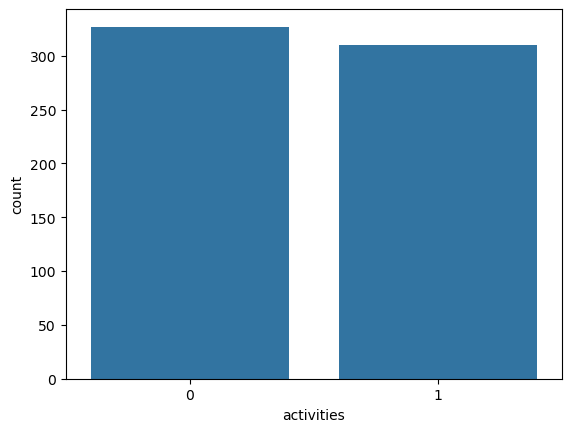

Countplot for internet


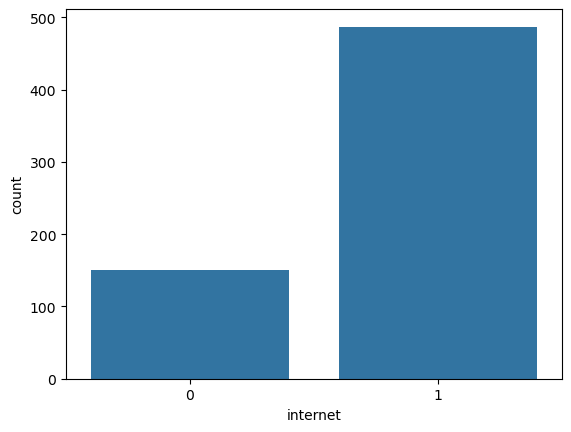

Countplot for goout


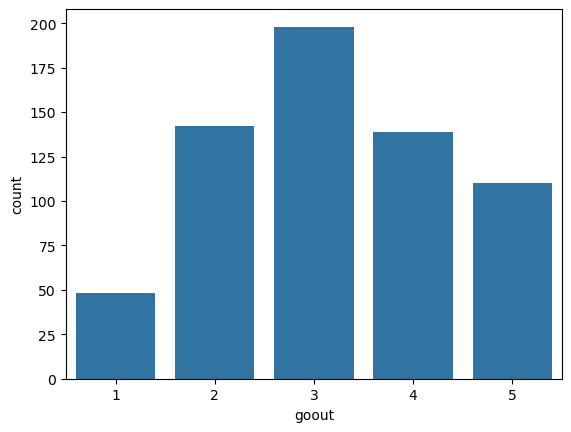

In [14]:
for i in cat_col:
    print(f"Countplot for {i}")
    sns.countplot(x=df[i])
    plt.show()

boxplot for absences


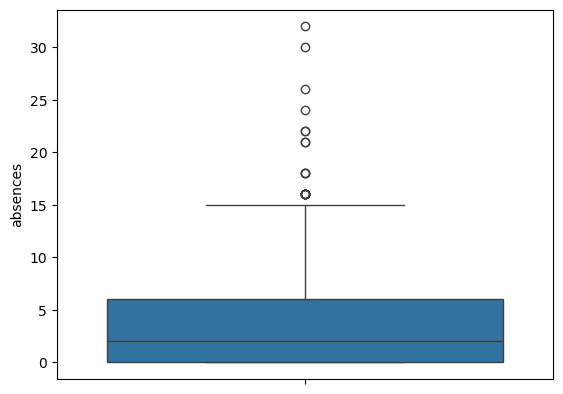

boxplot for G1


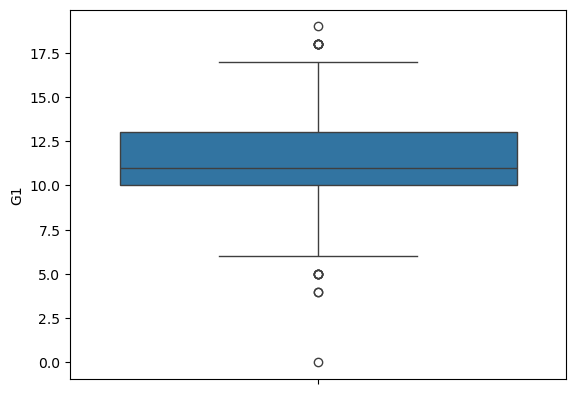

boxplot for G2


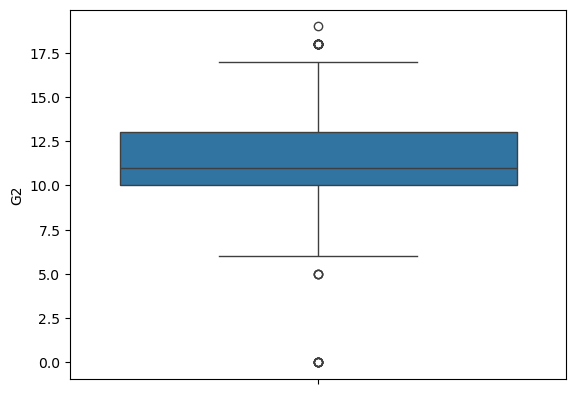

boxplot for G3


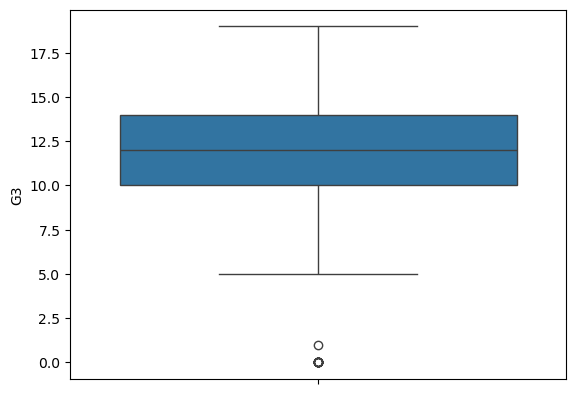

In [15]:
for i in num_col:
    print(f"boxplot for {i}")
    sns.boxplot(y=df[i] )
    plt.show()

<Axes: xlabel='internet', ylabel='G1'>

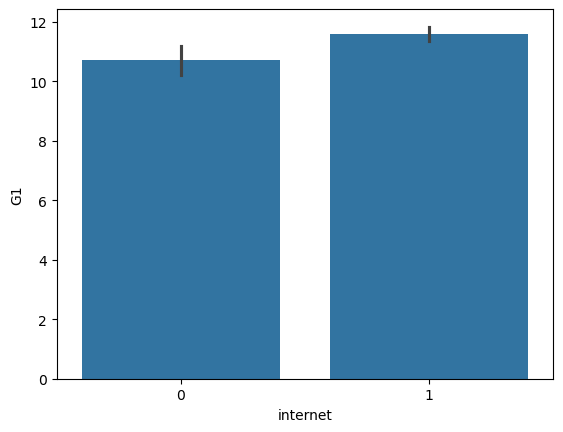

In [16]:
sns.barplot(x=df['internet'] , y= df['G1'])

<Axes: xlabel='internet', ylabel='G2'>

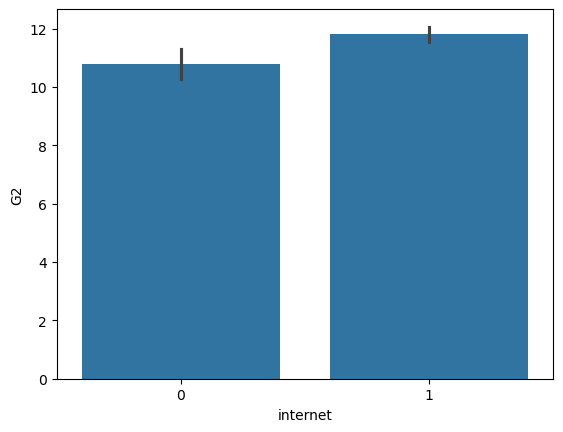

In [17]:
sns.barplot(x=df['internet'] , y= df['G2'])

<Axes: xlabel='internet', ylabel='G3'>

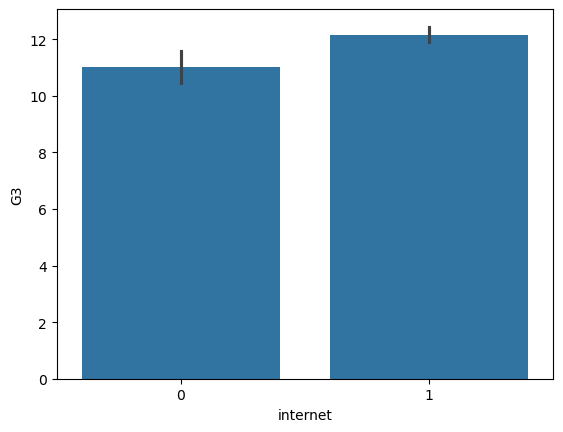

In [18]:
sns.barplot(x=df['internet'] , y= df['G3'])

In [19]:
df.describe()

,studytime,failures,activities,internet,absences,goout,G1,G2,G3
count,637.000000,637.000000,637.000000,637.000000,637.000000,637.000000,637.000000,637.000000,637.000000
mean,1.932496,0.226060,0.486656,0.764521,3.690738,3.189953,11.395604,11.565149,11.899529
std,0.833740,0.598015,0.500215,0.424631,4.661173,1.182961,2.758152,2.925852,3.248021
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,1.000000,0.000000,2.000000,10.000000,10.000000,10.000000
50%,2.000000,0.000000,0.000000,1.000000,2.000000,3.000000,11.000000,11.000000,12.000000
75%,2.000000,0.000000,1.000000,1.000000,6.000000,4.000000,13.000000,13.000000,14.000000
max,4.000000,3.000000,1.000000,1.000000,32.000000,5.000000,19.000000,19.000000,19.000000


In [20]:
## so all the three marks converge around the same number 

<Axes: xlabel='studytime', ylabel='G1'>

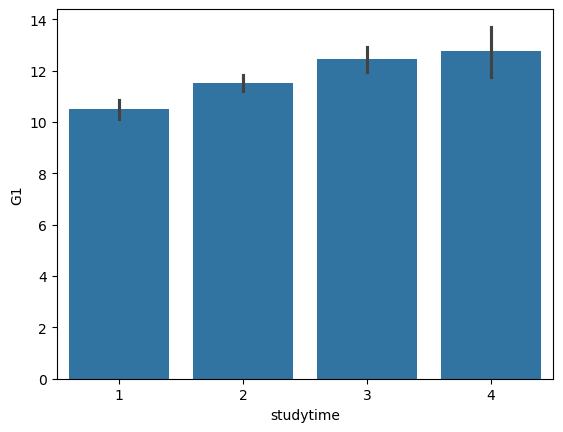

In [21]:
sns.barplot(x=df['studytime'] , y= df['G1'])

<Axes: xlabel='studytime', ylabel='G2'>

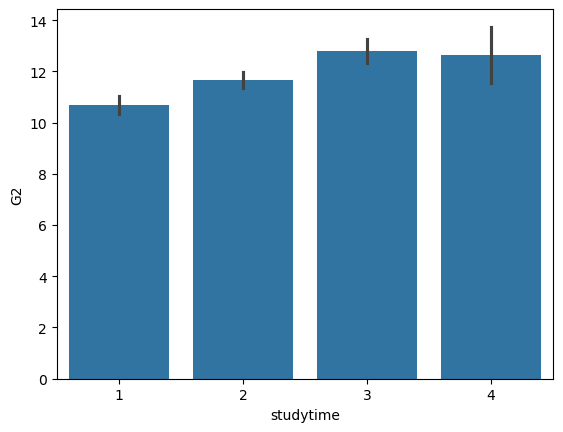

In [22]:
sns.barplot(x=df['studytime'] , y= df['G2'])

<Axes: xlabel='studytime', ylabel='G3'>

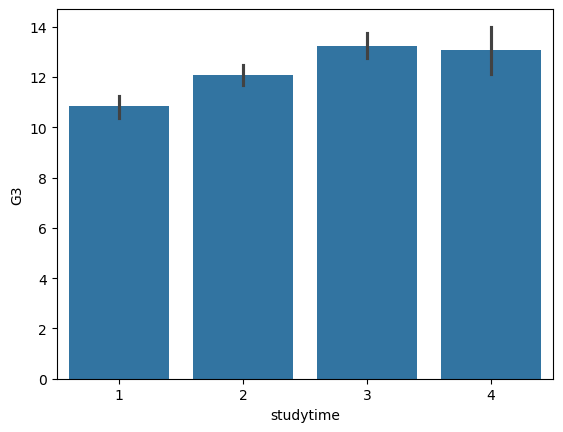

In [23]:
sns.barplot(x=df['studytime'] , y= df['G3'])

In [24]:
## studytime of 3 and 4 have " competitive marks "

In [25]:
df.head()

,studytime,failures,activities,internet,absences,goout,G1,G2,G3
0,2,0,0,0,4,4,0,11,11
1,2,0,0,1,2,3,9,11,11
2,2,0,0,1,6,2,12,13,12
3,3,0,1,1,0,2,14,14,14
4,2,0,0,0,0,2,11,13,13


<Axes: xlabel='G1', ylabel='G2'>

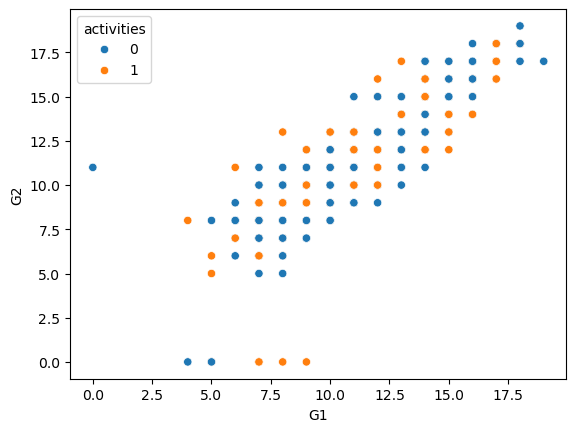

In [26]:
sns.scatterplot(x=df['G1'] , y=df['G2'] , hue=df['activities'])

In [27]:
df1 = df.copy()

In [28]:
def classify(score):
    if(score>=16):
        return "Excellent"
    elif(score>=12):
        return "Good"
    elif(score>=9):
        return "Average"
    else:
        return "Poor"


df['Performance'] = df['G3'].apply(classify)

In [29]:
df= df.drop_duplicates()

In [30]:
df1 = df

In [31]:
## Logistic Regression

In [32]:
X = df1.drop(columns = ["G3" , "Performance"])
Y = df1['Performance']

In [33]:
X.head()

,studytime,failures,activities,internet,absences,goout,G1,G2
0,2,0,0,0,4,4,0,11
1,2,0,0,1,2,3,9,11
2,2,0,0,1,6,2,12,13
3,3,0,1,1,0,2,14,14
4,2,0,0,0,0,2,11,13


In [34]:
Y.head()

0    Average
1    Average
2       Good
3       Good
4       Good
Name: Performance, dtype: object

## Logistic Regression 

In [35]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [36]:
X_train , X_test , Y_train , Y_test = train_test_split(X, Y , test_size=0.3 , random_state=42 , stratify= Y)
X_train.head()

,studytime,failures,activities,internet,absences,goout,G1,G2
162,1,0,0,1,0,5,12,11
522,2,0,0,1,4,4,8,8
476,1,0,0,1,2,3,10,8
552,2,2,1,1,2,3,9,9
410,2,0,1,1,0,4,13,17


In [37]:
X_test.head()

,studytime,failures,activities,internet,absences,goout,G1,G2
648,1,0,0,1,4,1,10,11
201,2,0,1,1,0,3,13,14
419,1,0,0,1,10,4,7,11
120,2,0,0,1,0,3,14,14
516,2,0,1,1,0,3,14,16


In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
logreg = LogisticRegression()

In [41]:
logreg.fit(X_train_scaled , Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [42]:
# 6. Make predictions
y_pred = logreg.predict(X_test_scaled)          # Predict discrete classes (0 or 1)
y_prob = logreg.predict_proba(X_test_scaled)    # Predict raw probabilities

In [43]:
print("Accuracy:", accuracy_score(Y_test, y_pred))

Accuracy: 0.828125


## Decision Tree 

In [44]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [45]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)

In [46]:
dt.fit(X_train , Y_train )

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [47]:
# Step 5: Make predictions on the test data
y_pred = dt.predict(X_test)



In [48]:
# Step 6: Evaluate performance
accuracy = accuracy_score(Y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

Model Accuracy: 88.54%



## Random Forest

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [50]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)


In [51]:
# 5. Train the model using the training data
rf.fit(X_train, Y_train)

# 6. Predict results on the unseen test data
y_pred = rf.predict(X_test)

# 7. Evaluate the model performance
accuracy = accuracy_score(Y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8385


## XGBoost

In [55]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [56]:
le = LabelEncoder()

In [57]:
import xgboost as xgb 

In [58]:
y_train_encoded = le.fit_transform(Y_train)
y_test_encoded = le.transform(Y_test)

In [59]:
# Initialize the model for multiclass prediction
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax', 
    num_class=len(le.classes_),  # Dynamic class count (e.g., 3 for three categories)
    random_state=42
)

In [60]:
xgb_model.fit(X_train, y_train_encoded)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [61]:
from sklearn.metrics import accuracy_score, classification_report

# Run predictions
y_pred = xgb_model.predict(X_test)

# Check accuracy and get detailed breakdown per class
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.8281


In [62]:
import joblib

In [63]:
from sklearn.tree import DecisionTreeClassifier

final_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

final_model.fit(X, Y)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [64]:
joblib.dump(final_model, "dt.pkl")

['dt.pkl']

In [65]:
loaded_model = joblib.load("dt.pkl")

In [66]:
X.head()

,studytime,failures,activities,internet,absences,goout,G1,G2
0,2,0,0,0,4,4,0,11
1,2,0,0,1,2,3,9,11
2,2,0,0,1,6,2,12,13
3,3,0,1,1,0,2,14,14
4,2,0,0,0,0,2,11,13


In [67]:
sample = [[
    3,
    0,
    1,
    1,
    4,
    2,
    14,
    15
]]

prediction = loaded_model.predict(sample)

print(prediction)

['Good']


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [68]:
import os

print(os.getcwd())

C:\Users\itsar\Documents\Untitled Folder
